In [1]:
# MK: Importing essential project libraries - processing & visualization
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa


In [2]:
# MK: Set data directory path for raw data, as raw data is not part of the repo. THIS MIGHT BE DIFFERENT ON YOUR MACHINE, PLEASE ADJUST ACCORDINGLY
data_dir = "../data/raw/NAYA_DATA_AUG1X"

In [3]:
# MK: Get all classes (subdirs) in the data directory and sort them
classes = []
for name in os.listdir(data_dir):
    if os.path.isdir(data_dir + "/" + name):
        classes.append(name)
classes.sort()
classes

['Angry',
 'Defence',
 'Fighting',
 'Happy',
 'HuntingMind',
 'Mating',
 'MotherCall',
 'Paining',
 'Resting',
 'Warning']

In [4]:
# MK: Create a dataframe with all the audio files and their corresponding labels
labels = []
filenames = []
is_aug = []

for label in classes:
    folder = data_dir + "/" + label
    for filename in os.listdir(folder):
        if filename.endswith(".mp3"):
            labels.append(label)
            filenames.append(filename)
            if "_aug" in filename:
                is_aug.append(True)
            else:
                is_aug.append(False)

df = pd.DataFrame()
df["label"] = labels
df["filename"] = filenames
df["is_aug"] = is_aug

print(len(df))
df.head()

5922


,label,filename,is_aug
0,Angry,car_extcoll0177.mp3,False
1,Angry,YashLL_Cat0274Ang.mp3,False
2,Angry,LastEntry_cat1265Ang.mp3,False
3,Angry,cat_flickr01407.mp3,False
4,Angry,Cat_angry1020_aug1(1).mp3,True


In [5]:
df["is_aug"].value_counts()

is_aug
False    2961
True     2961
Name: count, dtype: int64

In [6]:
# MK: Aug data is a full copy of the data set

In [7]:
df.groupby("label")["is_aug"].value_counts()

label        is_aug
Angry        False     300
             True      300
Defence      False     291
             True      291
Fighting     True      300
             False     300
Happy        False     297
             True      297
HuntingMind  False     289
             True      289
Mating       True      301
             False     301
MotherCall   True      296
             False     296
Paining      False     291
             True      291
Resting      True      296
             False     296
Warning      True      300
             False     300
Name: count, dtype: int64

In [ ]:
# MK: samples are not balanced across class, but the split between augmented and non-augmented data is balanced across classes

In [9]:
happy = df[df["label"] == "Happy"]
happy = happy.sort_values("filename")
happy.head(6)

,label,filename,is_aug
2300,Happy,1294_1256854279.mp3,False
2329,Happy,1294_1256854279_aug1(1).mp3,True
2285,Happy,1295_1256854283.mp3,False
2037,Happy,1295_1256854283_aug1(1).mp3,True
2224,Happy,1296_1256854286.mp3,False
2032,Happy,1296_1256854286_aug1(1).mp3,True


In [10]:
# MK: Example for Happy, sorted by filename: every original is followed by its augmented clone (is_aug True)

In [11]:
original_path = data_dir + "/Happy/Online_Cat0522Hpy.mp3"
clone_path = data_dir + "/Happy/Online_Cat0522Hpy_aug1(1).mp3"

y_original, sr = librosa.load(original_path, sr=16000) #sampling rate 16000
y_clone, sr = librosa.load(clone_path, sr=16000)

print(len(y_original), len(y_clone), sr)

70862 71698 16000


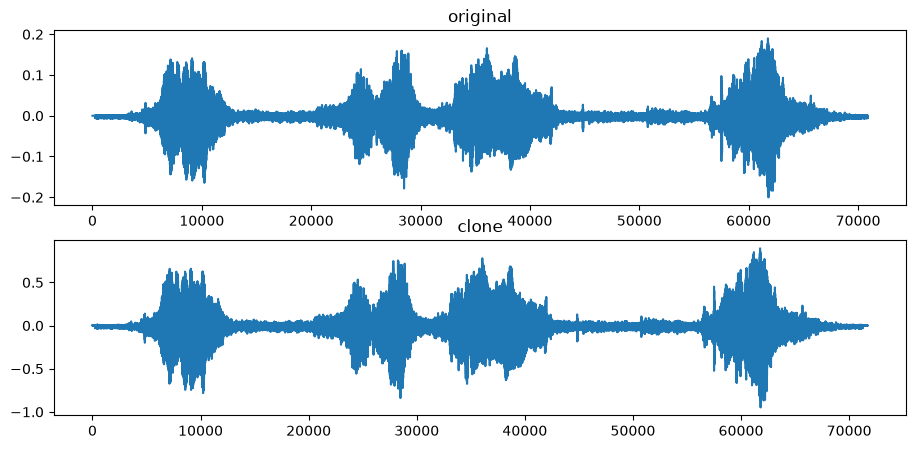

In [12]:
plt.figure(figsize=(11, 5))

plt.subplot(2, 1, 1)
plt.plot(y_original)
plt.title("original")

plt.subplot(2, 1, 2)
plt.plot(y_clone)
plt.title("clone")

plt.show()

In [13]:
# MK: notice it's the same sound, just the y-axis is different (sample two is louder)

In [14]:
# MK: show the examples's max volume, original vs.  clone
print(y_original.max())
print(y_clone.max())

0.18996733
0.89525783


In [15]:
durations = []

for i in range(len(df)):
    path = data_dir + "/" + df["label"][i] + "/" + df["filename"][i] # MK: get the path to the audio file
    duration = librosa.get_duration(path=path)                       # MK: get the duration of the audio file
    durations.append(duration)

df["duration"] = durations                                           # MK: add the duration column to the dataframe
df.head()

,label,filename,is_aug,duration
0,Angry,car_extcoll0177.mp3,False,7.053923
1,Angry,YashLL_Cat0274Ang.mp3,False,4.702902
2,Angry,LastEntry_cat1265Ang.mp3,False,8.281678
3,Angry,cat_flickr01407.mp3,False,3.344535
4,Angry,Cat_angry1020_aug1(1).mp3,True,2.768980


In [ ]:
originals = df[df["is_aug"] == False]
originals.groupby("label")["duration"].mean()

label
Angry          4.473289
Defence        1.749885
Fighting       3.625381
Happy          2.864228
HuntingMind    4.346337
Mating         4.935661
MotherCall     4.138065
Paining        3.811079
Resting        5.047331
Warning        3.629035
Name: duration, dtype: float64

In [17]:
originals.groupby("label")["duration"].median()

label
Angry          4.206576
Defence        1.489841
Fighting       3.357596
Happy          2.822086
HuntingMind    4.232698
Mating         4.755147
MotherCall     4.180454
Paining        3.631882
Resting        4.977188
Warning        3.305351
Name: duration, dtype: float64

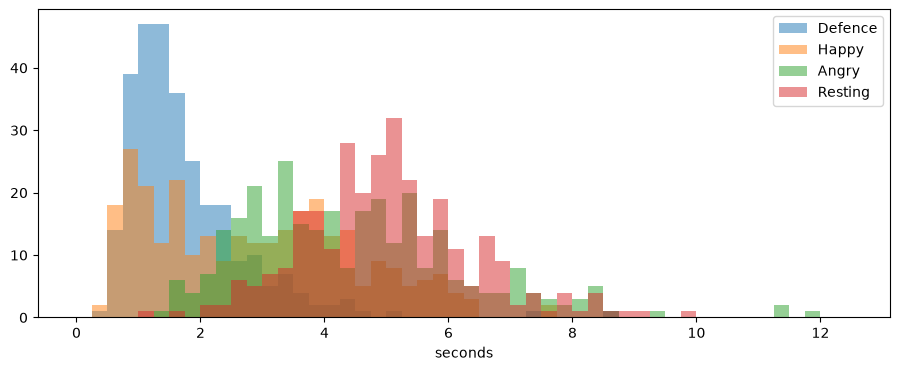

In [20]:
plt.figure(figsize=(11, 4)) # MK figsize defines the size of the figure in inches (width, height)

for label in ["Defence", "Happy", "Angry", "Resting"]:
    subset = originals[originals["label"] == label] # MK: get the subset of the dataframe for each label
    plt.hist(subset["duration"], bins=50, range=(0, 12.5), alpha=0.5, label=label) # MK: plot the histogram of the duration of the audio files for each label


plt.xlabel("seconds")
plt.legend()


In [ ]:
short = originals[originals["duration"] < 1] # MK: get the audio files with duration less than 1 second
short["label"].value_counts()

label
Defence       54
Happy         47
Fighting       3
MotherCall     3
Paining        3
Warning        2
Name: count, dtype: int64

In [ ]:
# MK: In essence: Duration is a shortcut: Defence mostly under 2 s, Resting mostly over 4 s. A model can read the class off the silence, not the sound.
# MK: Suggestion: Snip out the X milliseconds around the loudest part of the audio file, and then optinally pad with silence to a fixed length.